In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
full_df = pd.read_csv("apartmentInfo.csv", header=None).drop(0, axis=1)

In [3]:
df = full_df.iloc[:,:10]
amenities_df = full_df.iloc[:,10:]

temp_df = pd.DataFrame()
for index, values in amenities_df.iterrows():
    my_list = [values.unique()[:-1]]
    temp_df = pd.concat([temp_df, pd.Series(my_list)], ignore_index = True)

df = pd.concat([df, temp_df], axis = 1, ignore_index = True)

column_list = ["Name", "Address", "Floor Plan", "Price", "Bedrooms", "Bathrooms", "Size", "Availability", "Link", "Entry Type", "Amenities"]
column_dic = {}
for i in range(len(column_list)):
    column_dic[df.columns.values[i]] = column_list[i]

df = df.rename(columns = column_dic)
df

,Name,Address,Floor Plan,Price,Bedrooms,Bathrooms,Size,Availability,Link,Entry Type,Amenities
0,Accolade Minneapolis,2650 University Ave Minneapolis MN 55414,S1,$1180,Studio,1 Bath,389 Sq Ft,Availability date not found,https://accolademinneapolis.com/?switch_cls[id...,Key Fob Entry,"[Air Conditioning, Granite Countertops, Energy..."
1,Accolade Minneapolis,2650 University Ave Minneapolis MN 55414,S2,$1180,Studio,1 Bath,391 Sq Ft,Availability date not found,https://accolademinneapolis.com/?switch_cls[id...,Key Fob Entry,"[Air Conditioning, Granite Countertops, Energy..."
2,Accolade Minneapolis,2650 University Ave Minneapolis MN 55414,S1 Affordable,$1249,Studio,1 Bath,389 Sq Ft,Availability date not found,https://accolademinneapolis.com/?switch_cls[id...,Key Fob Entry,"[Air Conditioning, Granite Countertops, Energy..."
3,Accolade Minneapolis,2650 University Ave Minneapolis MN 55414,S3,$1305,Studio,1 Bath,391 Sq Ft,Availability date not found,https://accolademinneapolis.com/?switch_cls[id...,Key Fob Entry,"[Air Conditioning, Granite Countertops, Energy..."
4,Accolade Minneapolis,2650 University Ave Minneapolis MN 55414,A1,$1429,1 Bed,1 Bath,558 Sq Ft,Availability date not found,https://accolademinneapolis.com/?switch_cls[id...,Key Fob Entry,"[Air Conditioning, Granite Countertops, Energy..."
...,...,...,...,...,...,...,...,...,...,...,...
512,Blue Goose Cooperative,1819 5th St S Minneapolis MN 55454Leasing Offi...,The Wandering Raven,$875,Studio,1 Bath,373 Sq Ft,Availability date not found,https://mutualmgmtcompany.com/selection/,High Speed Internet Access,"[Air Conditioning, Heating, Ceiling Fans, Smok..."
513,Blue Goose Cooperative,1819 5th St S Minneapolis MN 55454Leasing Offi...,The Rockin' Robin,$1075,1 Bed,1 Bath,492 - 695 Sq Ft,Availability date not found,https://mutualmgmtcompany.com/selection/,High Speed Internet Access,"[Air Conditioning, Heating, Ceiling Fans, Smok..."
514,Blue Goose Cooperative,1819 5th St S Minneapolis MN 55454Leasing Offi...,The Wandering Raven,$1100,1 Bed,1 Bath,592 Sq Ft,Availability date not found,https://mutualmgmtcompany.com/selection/,High Speed Internet Access,"[Air Conditioning, Heating, Ceiling Fans, Smok..."
515,Blue Goose Cooperative,1819 5th St S Minneapolis MN 55454Leasing Offi...,The Stellar Jay,$1575,2 Beds,2 Baths,995 Sq Ft,Availability date not found,https://mutualmgmtcompany.com/selection/,High Speed Internet Access,"[Air Conditioning, Heating, Ceiling Fans, Smok..."


Potential Features:
- Location (Distance from a Central Point)
- Amount of Bathrooms/Beds
- Price
- Size
- Amenities (Specific ID for Each Kind)
- Price per Sq ft.


In [4]:
df["Bedrooms"].unique()

array(['Studio', '1 Bed', '2 Beds', '4 Beds', '3 Beds', '$1379', '$1389',
       '$469', '$479', '$489', '$829', '$849', '$874', '$929', '$835',
       '$930', '$529', '$595', ' 511B350H/L)', '$1454.25',
       'rent not found', '5 Beds', '6 Beds', 'B4-G'], dtype=object)

In [5]:
idx = 0
for value in df["Bedrooms"]:
    if value == "Studio":
        df.iloc[idx, 4] = "0"
    else:
        df.iloc[idx, 4] = value[0]
    idx += 1

In [6]:
idx = 0
for value in df["Bathrooms"]:
    df.iloc[idx, 5] = value[0]
    idx += 1

In [7]:
idx = 0
for value in df["Price"]:
    df.iloc[idx, 3] = value[1:]
    idx += 1

In [8]:
idx = 0
for value in df["Size"]:
    df.iloc[idx, 6] = value[:4]
    idx += 1

In [ ]:
df["Size"][:80]

array(['389 ', '391 ', '558 ', '559 ', '683 ', '949 ', '886 ', '801 ',
       '838 ', '776 ', '894 ', '1283', '460 ', '442 ', '417 ', '613 ',
       '624 ', '777 ', '800 ', '806 ', '1035', '1239', '850 ', '685 ',
       '780 ', '1420', '1423', '1107', '1495', '585 ', '673 ', '769 ',
       '787 ', '900 ', '1344', '1143', '1325', '1536', '1542', '1665',
       '1656', '1298', '1638', '1576', '1473', '1234', '2317', '1460',
       '1997', '1967', '468 ', '467 ', '583 ', '477 ', '515 ', '625 ',
       '675 ', '633 ', '611 ', '606 ', '674 ', '693 ', '767 ', '803 ',
       '975 ', '1070', '870 ', '865 ', '917 ', '853 ', '910 ', '486 ',
       '1153', '994 ', '1047', '1116', '882 ', '1380', '1457', '1314'],
      dtype=object)

In [22]:
df["Price"][:80]

0     1180
1     1180
2     1249
3     1305
4     1429
      ... 
75    1539
76    1569
77    1569
78    1639
79    1679
Name: Price, Length: 80, dtype: object

([<matplotlib.axis.XTick at 0x14ad45910>,
 [Text(259.0, 0, '1000'), Text(260.0, 0, '1500'), Text(142.0, 0, '2000')])

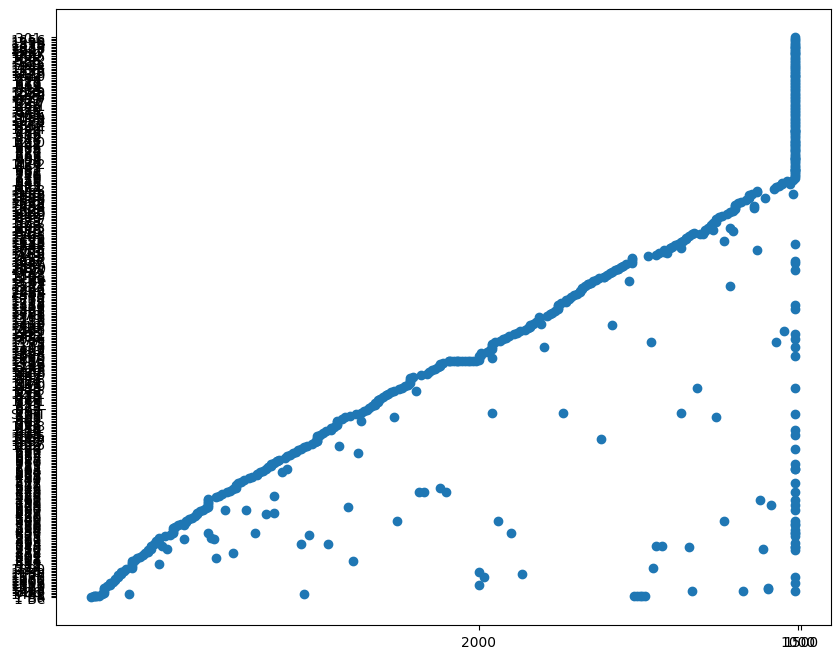

In [44]:
gs, ax = plt.subplots(figsize = (10,8))

plt.scatter(df.sort_values("Price")["Price"], df.sort_values("Price")["Size"])
plt.xticks(["1000", "1500", "2000"])


In [59]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
df['Bathrooms'] = pd.to_numeric(df['Bathrooms'], errors='coerce')
df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce')
df = df.dropna()

/var/folders/6_/lsyhrr_s6nj8zzg6gfbcn6600000gn/T/ipykernel_6568/2931973186.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
/var/folders/6_/lsyhrr_s6nj8zzg6gfbcn6600000gn/T/ipykernel_6568/2931973186.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Size'] = pd.to_numeric(df['Size'], errors='coerce')
/var/folders/6_/lsyhrr_s6nj8zzg6gfbcn6600000gn/T/ipykernel_6568/2931973186.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy 

In [60]:
print(df[["Price", "Size", "Bathrooms", "Bedrooms"]].corr())


              Price      Size  Bathrooms  Bedrooms
Price      1.000000  0.210233  -0.042251  0.015539
Size       0.210233  1.000000   0.789023  0.819584
Bathrooms -0.042251  0.789023   1.000000  0.787297
Bedrooms   0.015539  0.819584   0.787297  1.000000
